In [1]:
!pip install torch torchvision segmentation-models-pytorch albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

DATA_DIR = '/content/drive/MyDrive/GVP/merged_dataset'

In [4]:
import random, shutil
from pathlib import Path

random.seed(42)

src_images = Path(DATA_DIR) / 'images'
src_labels = Path(DATA_DIR) / 'labels'

out_dir = Path('/content/dataset')
if out_dir.exists():
    shutil.rmtree(out_dir)

for split in ['train', 'val', 'test']:
    (out_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (out_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

img_files = sorted([f for f in src_images.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
random.shuffle(img_files)

n = len(img_files)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

splits = {
    'train': img_files[:train_end],
    'val': img_files[train_end:val_end],
    'test': img_files[val_end:]
}

def copy_pair(files, split):
    for img_path in files:
        label_path = src_labels / (img_path.stem + '.txt')
        shutil.copy(img_path, out_dir / split / 'images' / img_path.name)
        if label_path.exists():
            shutil.copy(label_path, out_dir / split / 'labels' / label_path.name)

for split, files in splits.items():
    copy_pair(files, split)
    print(f"{split}: {len(files)} images")

train: 1125 images
val: 241 images
test: 242 images


In [5]:
import cv2
import numpy as np

CLASS_MAP = {0: 'Animal', 1: 'Waste', 2: 'Person'}
NUM_CLASSES = len(CLASS_MAP) + 1  # +1 for background

def yolo_polygon_to_mask(label_path, img_shape):
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    if not label_path.exists():
        return mask
    with open(label_path) as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        points = np.array(coords).reshape(-1, 2)
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(np.int32)
        cv2.fillPoly(mask, [points], color=cls_id + 1)
    return mask

for split in ['train', 'val', 'test']:
    img_dir = out_dir / split / 'images'
    label_dir = out_dir / split / 'labels'
    mask_dir = out_dir / split / 'masks'
    mask_dir.mkdir(exist_ok=True)
    for img_path in sorted(img_dir.iterdir()):
        img = cv2.imread(str(img_path))
        label_path = label_dir / (img_path.stem + '.txt')
        mask = yolo_polygon_to_mask(label_path, img.shape)
        cv2.imwrite(str(mask_dir / (img_path.stem + '.png')), mask)
    print(f"{split}: masks created")

train: masks created
val: masks created
test: masks created


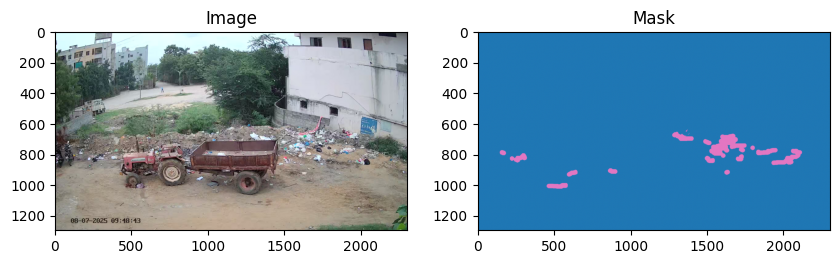

In [6]:
import matplotlib.pyplot as plt

sample_name = sorted((out_dir/'train'/'images').iterdir())[0]
sample_img = cv2.imread(str(sample_name))
sample_mask = cv2.imread(str(out_dir/'train'/'masks'/(sample_name.stem+'.png')), cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
ax[0].set_title('Image')
ax[1].imshow(sample_mask, cmap='tab10', vmin=0, vmax=3)
ax[1].set_title('Mask')
plt.show()

In [7]:
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 512

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class GarbageSegDataset(Dataset):
    def __init__(self, split, transforms=None):
        self.img_dir = out_dir / split / 'images'
        self.mask_dir = out_dir / split / 'masks'
        self.files = sorted(self.img_dir.iterdir())
        self.transforms = transforms

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        mask_path = self.mask_dir / (img_path.stem + '.png')

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.long()

train_ds = GarbageSegDataset('train', train_tfms)
val_ds = GarbageSegDataset('val', val_tfms)
test_ds = GarbageSegDataset('test', val_tfms)

print(len(train_ds), len(val_ds), len(test_ds))

1125 241 242


In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [9]:
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',   # pretrained -> fine-tuning
    in_channels=3,
    classes=NUM_CLASSES            # background + 3 classes = 4
).to(device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [10]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

def compute_iou(preds, masks, num_classes):
    ious = []
    preds = preds.view(-1)
    masks = masks.view(-1)
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = masks == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return ious

In [11]:
import numpy as np

EPOCHS = 35
PATIENCE = 10
best_val_loss = float('inf')
patience_counter = 0

SAVE_DIR = Path('/content/drive/MyDrive/garbage_runs/unet_v1')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

history = {'train_loss': [], 'val_loss': [], 'val_miou': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    all_ious = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            ious = compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES)
            all_ious.append(ious)
    val_loss /= len(val_loader)
    mean_iou_per_class = np.nanmean(all_ious, axis=0)
    val_miou = np.nanmean(mean_iou_per_class)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_miou'].append(val_miou)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_unet.pt')
        print("  -> saved best model")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

Epoch 1/35 | Train Loss: 0.6204 | Val Loss: 0.2892 | Val mIoU: 0.3704
  -> saved best model
Epoch 2/35 | Train Loss: 0.1920 | Val Loss: 0.1978 | Val mIoU: 0.4293
  -> saved best model
Epoch 3/35 | Train Loss: 0.1083 | Val Loss: 0.1298 | Val mIoU: 0.4582
  -> saved best model
Epoch 4/35 | Train Loss: 0.0830 | Val Loss: 0.0817 | Val mIoU: 0.4696
  -> saved best model
Epoch 5/35 | Train Loss: 0.0671 | Val Loss: 0.0883 | Val mIoU: 0.4957
Epoch 6/35 | Train Loss: 0.0610 | Val Loss: 0.0739 | Val mIoU: 0.4919
  -> saved best model
Epoch 7/35 | Train Loss: 0.0565 | Val Loss: 0.0833 | Val mIoU: 0.4867
Epoch 8/35 | Train Loss: 0.0529 | Val Loss: 0.0730 | Val mIoU: 0.4836
  -> saved best model
Epoch 9/35 | Train Loss: 0.0507 | Val Loss: 0.0675 | Val mIoU: 0.4999
  -> saved best model
Epoch 10/35 | Train Loss: 0.0473 | Val Loss: 0.0648 | Val mIoU: 0.5129
  -> saved best model
Epoch 11/35 | Train Loss: 0.0413 | Val Loss: 0.0627 | Val mIoU: 0.5257
  -> saved best model
Epoch 12/35 | Train Loss: 0.03

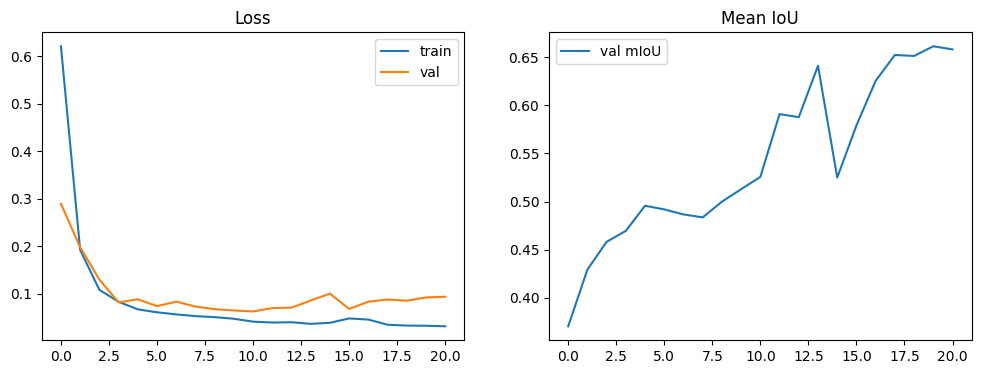

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history['val_miou'], label='val mIoU')
plt.legend(); plt.title('Mean IoU')
plt.savefig(SAVE_DIR / 'training_curves.png')
plt.show()

In [13]:
model.load_state_dict(torch.load(SAVE_DIR / 'best_unet.pt'))
model.eval()

all_ious = []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        ious = compute_iou(preds.cpu(), masks.cpu(), NUM_CLASSES)
        all_ious.append(ious)

mean_iou_per_class = np.nanmean(all_ious, axis=0)
class_names = ['background'] + list(CLASS_MAP.values())

for name, iou in zip(class_names, mean_iou_per_class):
    print(f"{name}: IoU = {iou:.4f}")

print(f"Mean IoU (all classes): {np.nanmean(mean_iou_per_class):.4f}")
print(f"Mean IoU (excluding background): {np.nanmean(mean_iou_per_class[1:]):.4f}")

background: IoU = 0.9777
Animal: IoU = 0.0529
Waste: IoU = 0.6483
Person: IoU = 0.3349
Mean IoU (all classes): 0.5035
Mean IoU (excluding background): 0.3454


In [14]:
import json

summary = {
    "model": "unet_resnet34",
    "epochs_run": len(history['train_loss']),
    "final_val_miou": history['val_miou'][-1],
    "test_iou_per_class": dict(zip(class_names, mean_iou_per_class.tolist())),
    "test_mean_iou_excl_bg": float(np.nanmean(mean_iou_per_class[1:])),
    "classes": CLASS_MAP
}

with open(SAVE_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(summary)

{'model': 'unet_resnet34', 'epochs_run': 21, 'final_val_miou': np.float64(0.6581972134161872), 'test_iou_per_class': {'background': 0.977691042639368, 'Animal': 0.05294681622651577, 'Waste': 0.6483184485203073, 'Person': 0.33491952004777886}, 'test_mean_iou_excl_bg': 0.34539492826486734, 'classes': {0: 'Animal', 1: 'Waste', 2: 'Person'}}


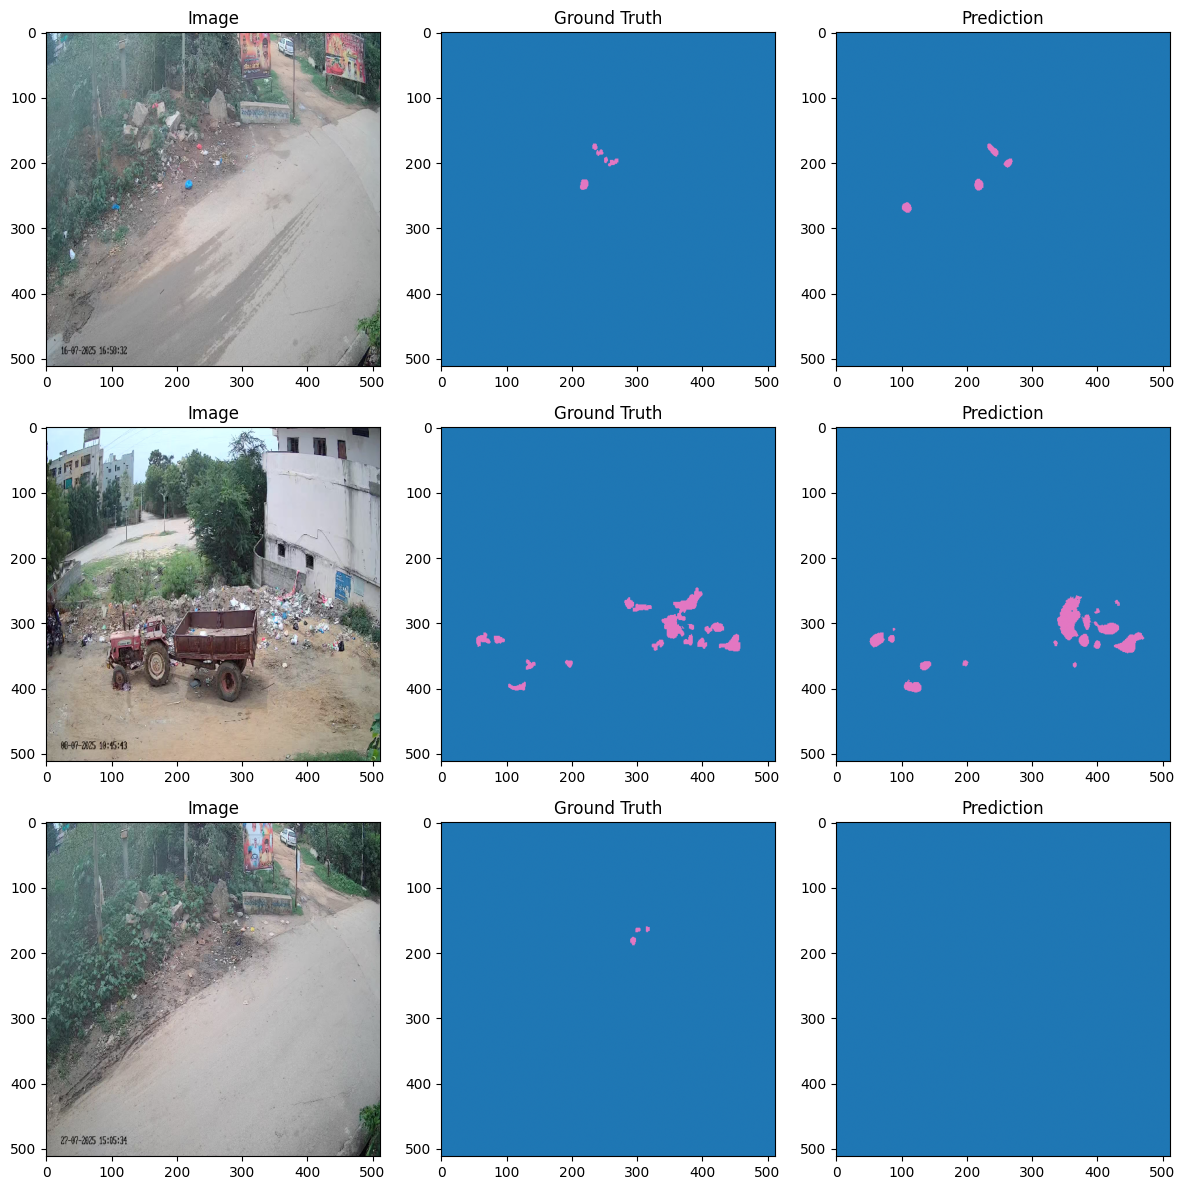

In [15]:
model.eval()
imgs, masks = next(iter(test_loader))
with torch.no_grad():
    outputs = model(imgs.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12,12))
for i in range(3):
    img = imgs[i].permute(1,2,0).numpy()
    img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
    axes[i,0].imshow(img); axes[i,0].set_title('Image')
    axes[i,1].imshow(masks[i], cmap='tab10', vmin=0, vmax=3); axes[i,1].set_title('Ground Truth')
    axes[i,2].imshow(preds[i], cmap='tab10', vmin=0, vmax=3); axes[i,2].set_title('Prediction')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'sample_predictions.png')
plt.show()

In [17]:
import numpy as np

class_pixel_counts = np.zeros(NUM_CLASSES)
for mask_path in (out_dir/'train'/'masks').iterdir():
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    for c in range(NUM_CLASSES):
        class_pixel_counts[c] += (mask == c).sum()

total = class_pixel_counts.sum()
for i, name in enumerate(['background'] + list(CLASS_MAP.values())):
    print(f"{name}: {class_pixel_counts[i]:.0f} pixels ({100*class_pixel_counts[i]/total:.2f}%)")

background: 3752495239 pixels (92.06%)
Animal: 3008164 pixels (0.07%)
Waste: 282406283 pixels (6.93%)
Person: 38107786 pixels (0.93%)


In [19]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00


In [21]:
# mean iou calculation for yolo model
from ultralytics import YOLO
import numpy as np, cv2

yolo_model = YOLO('/content/drive/MyDrive/garbage_runs/seg_correct_v2/weights/best.pt')

test_img_dir = out_dir / 'test' / 'images'
test_mask_dir = out_dir / 'test' / 'masks'

all_ious = []
for img_path in sorted(test_img_dir.iterdir()):
    gt_mask = cv2.imread(str(test_mask_dir / (img_path.stem + '.png')), cv2.IMREAD_GRAYSCALE)
    h, w = gt_mask.shape

    results = yolo_model.predict(source=str(img_path), verbose=False)
    r = results[0]

    pred_mask = np.zeros((h, w), dtype=np.uint8)
    if r.masks is not None:
        for mask, cls in zip(r.masks.data, r.boxes.cls):
            m = cv2.resize(mask.cpu().numpy(), (w, h))
            pred_mask[m > 0.5] = int(cls) + 1

    ious = compute_iou(torch.tensor(pred_mask), torch.tensor(gt_mask), NUM_CLASSES)
    all_ious.append(ious)

yolo_mean_iou_per_class = np.nanmean(all_ious, axis=0)
class_names = ['background'] + list(CLASS_MAP.values())
for name, iou in zip(class_names, yolo_mean_iou_per_class):
    print(f"{name}: IoU = {iou:.4f}")
print(f"Mean IoU (excl background): {np.nanmean(yolo_mean_iou_per_class[1:]):.4f}")

background: IoU = 0.9689
Animal: IoU = 0.3245
Waste: IoU = 0.5668
Person: IoU = 0.4403
Mean IoU (excl background): 0.4439
